In [1]:
%load_ext autoreload
%autoreload 2

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

pd.options.display.float_format = '{:.2f}'.format

In [72]:
from ames_utils.cleaning import clean_data, print_missing
from ames_utils.data_manager import DataManager

SEED = 123

In [73]:
df = DataManager.load_csv(filename='AmesHousing.csv')

In [74]:
df_clean = clean_data(df)

DataManager.save_csv(df=df_clean, filename='ames_cleaned')

In [6]:
print_missing(df_clean)

Series([], dtype: int64)


# Feature Engineering

Dropping redundant columns

In [98]:
df_tr = df_clean.copy(deep=True)
df_tr.drop(['Order', 'PID'], axis=1, inplace=True)

In [76]:
numerical_cols = df_clean.dtypes[df_clean.dtypes !='str'].index
categorical_cols = df_clean.dtypes[df_clean.dtypes =='str'].index

## 1.1) Feature transformations - Mapping ordinal categorical columns
This dataset contains a variety of categorical features. Many of them are ordinal, meaning their values follow a natural hierarchy (e.g. columns describing quality such as `BsmtQual`). These features will be mapped using numeric values to preserve that order and prevent data sparsity while One-Hot Encoding rest of the categorical variables.

In [99]:
#1 Quality columns
mapping_qual = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0}
qual_cols = ['ExterQual', 'ExterCond','BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
   df_tr[col] = df_tr[col].map(mapping_qual)

#2 Basement Exposure
mapping_exp = {'Gd':4, 'Av':3, 'Mn':2, 'No':1, 'None':0}

df_tr['BsmtExposure'] = df_tr['BsmtExposure'].map(mapping_exp)

#3 Basement finish
mapping_fin = {'GLQ':6, 'ALQ':5, 'BLQ':4, 'Rec':3, 'LwQ':2, 'Unf':1, 'None':0}

for col in ['BsmtFinType1', 'BsmtFinType2']:
   df_tr[col] = df_tr[col].map(mapping_fin)

#4 Central Conditioning
df_tr['CentralAir'] = df_tr['CentralAir'].map({'Y':1, 'N':0})

#5 Garage finish
mapping_gar = {'Fin':3, 'RFn':2, 'Unf':1, 'None':0}
df_tr['GarageFinish'] = df_tr['GarageFinish'].map(mapping_gar)

#6 Paved driveway
mapping_drive = {'Y':2, 'P':1, 'N':0}
df_tr['PavedDrive'] = df_tr['PavedDrive'].map(mapping_drive)

#7 Fence quality
mapping_fence = {'GdPrv':4, 'MnPrv':3, 'GdWo':2, 'MnWw':1, 'None':0}
df_tr['Fence'] = df_tr['Fence'].map(mapping_fence)

#8 Slope of property
mapping_slope = {'Gtl':0, 'Mod':1,  'Sev':2}
df_tr['LandSlope'] = df_tr['LandSlope'].map(mapping_slope)


Transforming `Neighborhood` column using Target-Encoding. By calculating the median `Sale Price` for each neighborhood, locations were clustered into 3 distinct 'luxury' tiers using `pd.qcut`

In [100]:
nbh_medians = df_tr.groupby('Neighborhood')['SalePrice'].median().sort_values()
print(nbh_medians)

mapping_nbh = pd.qcut(nbh_medians, q=3, labels=[1,2,3])
df_tr['Neighborhood'] = df_tr['Neighborhood'].map(mapping_nbh).astype(int)


Neighborhood
MeadowV    88250.00
BrDale    106000.00
IDOTRR    106500.00
OldTown   119900.00
Edwards   125000.00
BrkSide   126750.00
Blueste   130500.00
Sawyer    135000.00
SWISU     136200.00
Landmrk   137000.00
NAmes     140000.00
NPkVill   143750.00
Mitchel   153500.00
SawyerW   180000.00
NWAmes    181000.00
Gilbert   183000.00
Blmngtn   191500.00
ClearCr   197500.00
Greens    198000.00
CollgCr   200000.00
Crawfor   200624.00
Somerst   225500.00
Timber    232106.50
Veenker   250250.00
GrnHill   280000.00
NoRidge   302000.00
NridgHt   317750.00
StoneBr   319000.00
Name: SalePrice, dtype: float64


# 1.2) Engineering new features from the dataset 

In [17]:
#1 Creating an interaction feature from two most influential features
df_tr['quality_area'] = df_tr['GrLivArea'] * df_tr['OverallQual']

#2 Above ground area + basement area
df_tr['total_house_area'] = df_tr['GrLivArea'] + df_tr['TotalBsmtSF']

#3 Area of all porch types combined into one variable
df_tr['total_porch_area'] = df_tr['OpenPorchSF'] + df_tr['EnclosedPorch'] + df_tr['3SsnPorch'] + df_tr['ScreenPorch'] + df_tr['WoodDeckSF']

#4 Binary flag based on calculated area
df_tr['has_porch'] = df_tr['total_porch_area'] > 0

#5 Total number of bathrooms (above ground + basement) (half baths are assigned a weight of 0.5)
df_tr['total_baths'] = df_tr['FullBath'] + (df_tr['HalfBath'] * 0.5) + df_tr['BsmtFullBath'] + (df_tr['BsmtHalfBath'] * 0.5)

#6 Combining quality with condition
df_tr['total_qual'] = df_tr['OverallQual'] + df_tr['OverallCond']

#7 Average room size (including bathrooms and kitchen)
df_tr['avg_room_area'] = df_tr['GrLivArea'] / (df_tr['TotRmsAbvGrd'] + df_tr['KitchenAbvGr'] + df_tr['FullBath'] + df_tr['HalfBath']) 

#8 Binary flag indicating whether a house had undergone any renovations (according to the documentation if there was no renovation, YearRemod/Add = YearBuilt) 
df_tr['was_renovated'] = df_tr['YearBuilt'] != df_tr['YearRemod/Add']

#9 Calculating age of a house during sale (it might carry much more information than the YearBuilt column)
df_tr['age_at_sale'] = df_tr['YrSold'] - df_tr['YearBuilt']

#10 Cyclical Encoding Sale Month column using sin and cos trig functions  
df_tr['month_sin'] = np.sin(2 * np.pi * df_tr['MoSold']/12)
df_tr['month_cos'] = np.cos(2 * np.pi * df_tr['MoSold']/12)
df_tr.drop('MoSold', axis=1, inplace=True)

Log transforming `SalePrice` column.

In [81]:
df_tr['log_SalePrice'] = np.log1p(df_tr['SalePrice'])

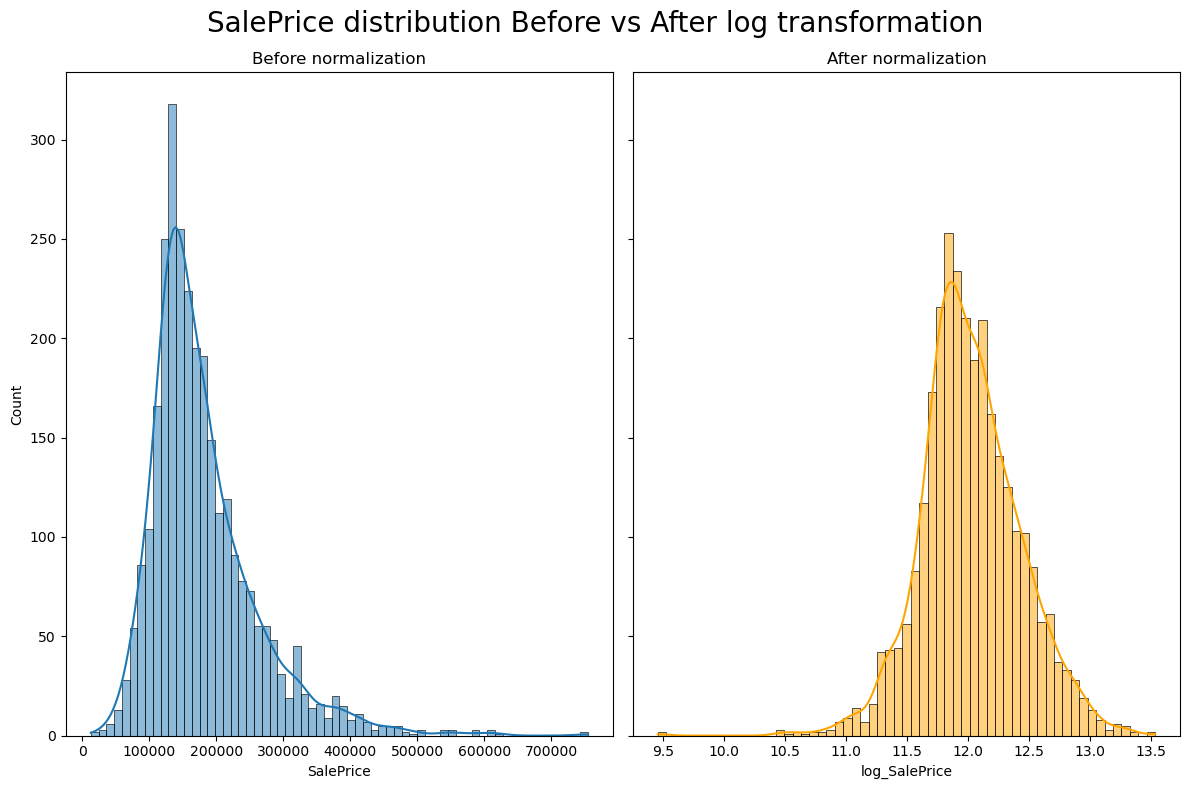

In [83]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8), sharey=True)

sns.histplot(data=df_tr, x='SalePrice', kde=True, ax=ax[0])
sns.histplot(data=df_tr, x='log_SalePrice', kde=True, ax=ax[1], color='orange')
ax[0].set_title('Before normalization')
ax[1].set_title('After normalization')
plt.suptitle('SalePrice distribution Before vs After log transformation', fontsize=20)
plt.tight_layout()
plt.show()

In [33]:
df_tr.drop('SalePrice', axis=1, inplace=True)

In [84]:
DataManager.save_csv(df_tr, 'ames_transformed')

One-hot encoding rest of the categorical features.

In [34]:
df_dummies = pd.get_dummies(df_tr)
df_dummies.shape

(2930, 230)